In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Markov Chain Monte Carlo

## Monte Carlo

It is an integration method

[]

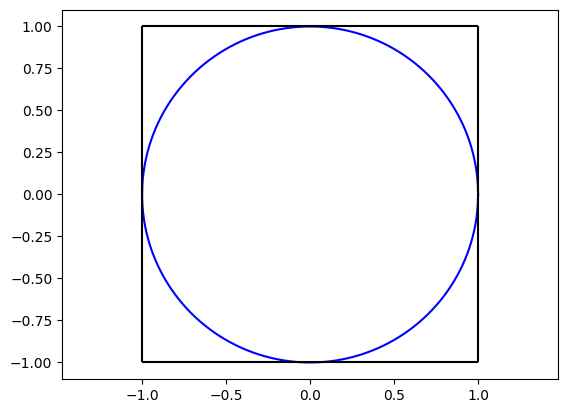

In [2]:
x = np.linspace(-1,1,1000)
plt.plot(x, np.sqrt(1-x**2), color='b')
plt.plot(x, -np.sqrt(1-x**2), color='b')
plt.vlines(x=-1, ymin=-1,ymax=1, color='k')
plt.vlines(x=1, ymin=-1,ymax=1, color='k')
plt.hlines(y=-1, xmin=-1,xmax=1, color='k')
plt.hlines(y=1, xmin=-1,xmax=1, color='k')
plt.axis('equal')
plt.plot()

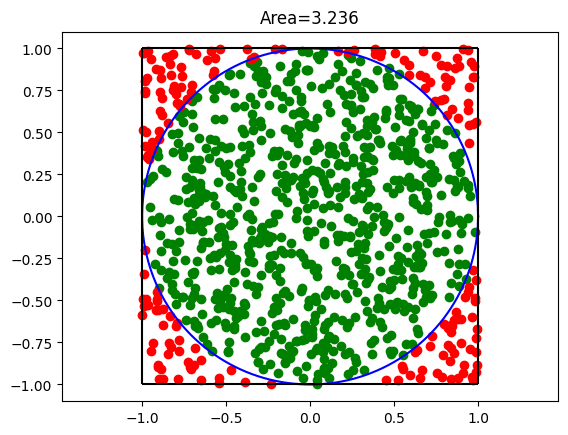

In [3]:
x = np.linspace(-1,1,1000)
plt.plot(x, np.sqrt(1-x**2), color='b')
plt.plot(x, -np.sqrt(1-x**2), color='b')
plt.vlines(x=-1, ymin=-1,ymax=1, color='k')
plt.vlines(x=1, ymin=-1,ymax=1, color='k')
plt.hlines(y=-1, xmin=-1,xmax=1, color='k')
plt.hlines(y=1, xmin=-1,xmax=1, color='k')
plt.axis('equal')
plt.plot()

n_data = 1000

xdata = np.random.rand(n_data)*2-1
ydata = np.random.rand(n_data)*2-1

inside = (ydata < np.sqrt(1-xdata**2)) & (ydata > -np.sqrt(1-xdata**2))

plt.scatter(xdata[inside], ydata[inside], color='green')
plt.scatter(xdata[~inside], ydata[~inside], color='red')

plt.title('Area={}'.format(np.mean(inside)*4))

plt.show()

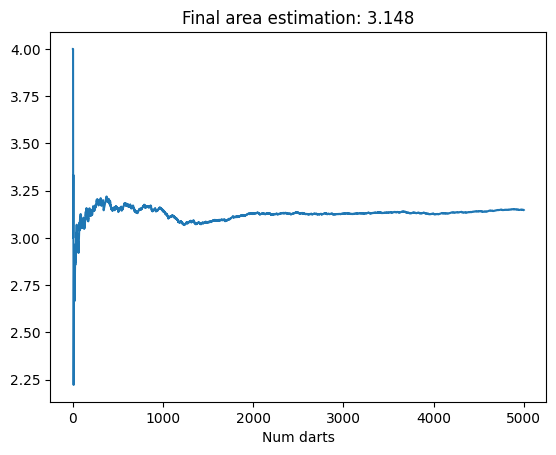

In [4]:
xdata = []
ydata = []
area = []

n_data = 5000

for i in range(n_data):
  xdata.append(np.random.rand(1)*2-1)
  ydata.append(np.random.rand(1)*2-1)
  inside = (np.array(ydata) < np.sqrt(1-np.array(xdata)**2)) & (np.array(ydata) > -np.sqrt(1-np.array(xdata)**2))
  area.append(np.mean(inside)*4)

plt.plot(range(n_data), area)
plt.title('Final area estimation: {}'.format(area[-1]))
plt.xlabel('Num darts')
plt.show()

In [5]:
np.mean(inside)

np.float64(0.787)

## Markov Chains

So we begin the following procedure.

* Draw a ball from $C$
  - If it says "A"
    + take a ball from $A$ and put it in $B$.
    + After this, change the label of the ball drawn from C to "B"
  - If it says "B"
    + take a ball from $B$ and put it in $A$.
    + After this, change the label of the ball drawn from C to "A"
* Put the labeled ball back in $C$.

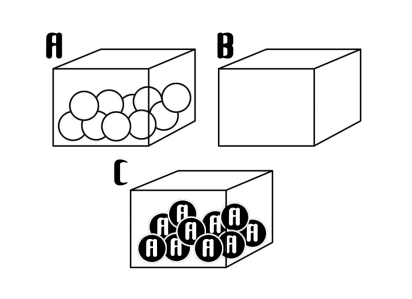

In [6]:
from scipy.stats import bernoulli

In [7]:
np.random.rand()

0.6131783025942421

In [8]:
balls_A = 10
balls_B = 0

for i in range(5):
  if np.random.rand() < balls_A/(balls_A + balls_B):
    if balls_A > 0:
      balls_A = balls_A - 1
      balls_B = balls_B + 1
  else:
    if balls_B > 0:
      balls_A = balls_A + 1
      balls_B = balls_B - 1

  print('Balls in A:', balls_A)
  print('Balls in B:', balls_B)
  print('')

Balls in A: 9
Balls in B: 1

Balls in A: 8
Balls in B: 2

Balls in A: 7
Balls in B: 3

Balls in A: 6
Balls in B: 4

Balls in A: 7
Balls in B: 3



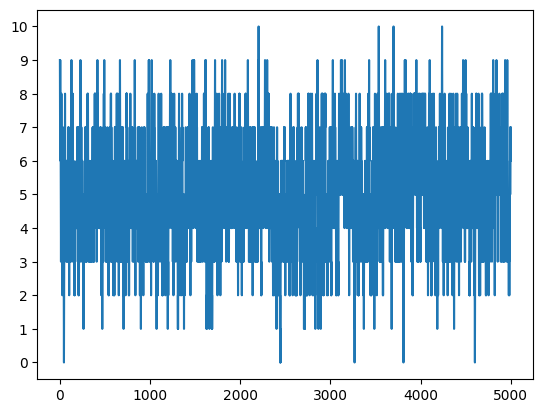

In [9]:
balls_A = 10
balls_B = 0

history_A = []

for i in range(5000):
  if np.random.rand()< balls_A/(balls_A + balls_B):
    if balls_A > 0:
      balls_A = balls_A - 1
      balls_B = balls_B + 1
  else:
    if balls_B > 0:
      balls_A = balls_A + 1
      balls_B = balls_B - 1

  history_A.append(balls_A)

plt.plot(history_A)
plt.yticks([0,1,2,3,4,5,6,7,8,9,10])
plt.show()

At step 0 we have $N$ balls in $A$.

At the first step, the probability of getting a ball labeled "A" from $C$ is 1, since all $N$ balls say the same thing. Therefore at step 1 we will have $N-1$ balls in $A$.

Or more clearly: Let $Y_i$="Number of balls in $A$ at step $i$", then

\begin{align*}
Y_0= & N, \ \ \text{ and}\\
Y_1= & N-1.
\end{align*}

But for step 2, there is the possibility of returning the ball we changed before or sending another one to $B$. In fact the probability of that event is known, since we know how many balls in $C$ say "B": exactly one. So

\begin{align*}
P(Y_2= N) & = \frac{1}{N}, \ \ \text{ and}\\
P(Y_2= N-2) & = \frac{N-1}{N}.
\end{align*}

In general the number of balls in $A$ at step $k$ depends on the number of balls at step $k-1$ and nothing else, that is
$$ P(Y_k=n_k|Y_{k-1}=n_{k-1},Y_{k-2}=n_{k-2},\dots,Y_0=N)=P(Y_k=n_k|Y_{k-1}=n_{k-1}). $$


This is called the *Markov property*. If we think of $Y_t$ as a process with $N+1$ possible states $0,1,2,\dots,N$, we can write the transition probability matrix between each of them as

$$
\left.
T =
\left( {\begin{array}{ccccccc}
 0           & 1           & 0             & 0             & & 0 \\
 \frac{1}{N} & 0           & \frac{N-1}{N} & 0             &\dots & 0\\
 0           & \frac{2}{N} & 0             & \frac{N-2}{N} & & 0\\
 0           & 0           &\frac{3}{N}    & 0             &  & 0\\
             &             & \vdots        &               &\ddots  & \frac{1}{N}\\
 0           & 0           & 0             & 0             & 1      & 0
 \end{array} } \right)
\right\} N+1.$$



### Markov Chain

Let $Y=\{Y_n \, | \, n\geq 0\}$ be a sequence of random variables defined on a state space $S$. $Y$ is said to be a Markov chain if

\begin{align*}
 P(Y_k=x_k|Y_{k-1}=x_{k-1},Y_{k-2}=x_{k-2},\dots,Y_0=x_0)=P(Y_k=x_k|Y_{k-1}=x_{k-1}) &\ , \\
\forall k\geq 1 , x_1,\dots,x_{n-1}\in S.&
\end{align*}

The joint distribution of a Markov chain is given by

* The marginal distribution of $Y_0$, called the **initial distribution**
* The conditional distribution of $Y_k$ given the value of $Y_{k-1}$, called the **transition probability**.


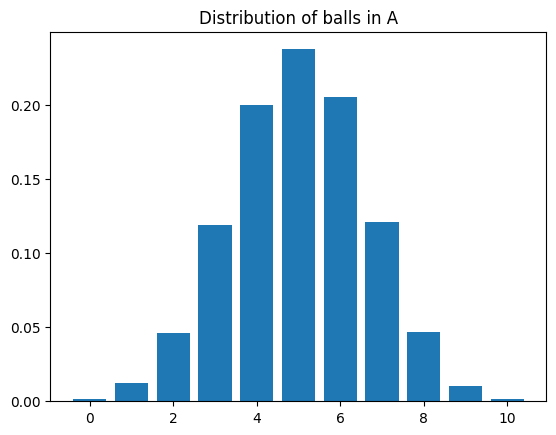

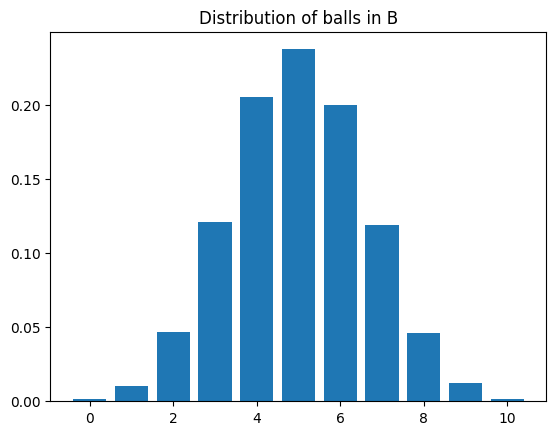

In [10]:
balls_A = 10
balls_B = 0

history_A = []
history_B = []

for i in range(4000):
  if np.random.rand()< balls_A/(balls_A + balls_B):
    if balls_A > 0:
      balls_A = balls_A - 1
      balls_B = balls_B + 1
  else:
    if balls_B > 0:
      balls_A = balls_A + 1
      balls_B = balls_B - 1

  history_A.append(balls_A)
  history_B.append(balls_B)

unique, counts = np.unique(history_A, return_counts=True)
plt.bar(unique, counts / np.sum(counts))
plt.title('Distribution of balls in A')
plt.show()

unique, counts = np.unique(history_B, return_counts=True)
plt.bar(unique, counts / np.sum(counts))
plt.title('Distribution of balls in B')
plt.show()

## Gibbs Sampling
Suppose we have a function $f(x,\theta_1,\dots,\theta_k)$ and we are interested in knowing something about the marginal function $f(x)$; however, we don't know the analytical form of the function. That is, we don't know how to compute
$$f(x)=\iint \cdots \int \, f(x,\theta_1,\theta_2,\dots,\theta_k) \ d\theta_1 \, d\theta_2 \cdots d\theta_k.$$

However, we do know how to simulate from the full conditionals
\begin{gather*}
f(x\, |\, \theta_1,\theta_2,\theta_3,\dots,\theta_k) \ ,\\
f(\theta_1\, | \, x,\theta_2,\theta_3,\dots,\theta_{k}) \ ,\\
f(\theta_2\, | \, x,\theta_1,\theta_3,\dots,\theta_{k}) \ ,\\
\vdots \\
f(\theta_k\, | \, x,\theta_2,\theta_3,\dots,\theta_{k-1}).
\end{gather*}

Then we can simulate $x^{(1)},x^{(2)},x^{(3)},\dots \sim f(x)$ using a Gibbs sampler as explained below.

First choose an initial point $\left(x^{(0)},\theta_1^{(0)},\theta_2^{(0)},\dots,\theta_k^{(0)}\right)$, which can be fixed or come from a probability distribution.

The $i$-th iteration of the algorithm consists of simulating from the following distributions:

* $x^{(i)}\ \sim \ f(x\, |\, \theta_1^{(i-1)},\theta_2^{(i-1)},\theta_3^{(i-1)},\theta_4^{(i-1)},\dots,\theta_k^{(i-1)}) $
* $\theta_1^{(i)} \ \sim \ f(\theta_1\, | \, x^{(i)},\theta_2^{(i-1)},\theta_3^{(i-1)},\theta_4^{(i-1)},\dots,\theta_{k}^{(i-1)})$
* $\theta_2^{(i)} \ \sim \ f(\theta_2\, | \, x^{(i)},\theta_1^{(i)},\theta_3^{(i-1)},\theta_4^{(i-1)},\dots,\theta_{k}^{(i-1)})$ \\
* $\theta_3^{(i)} \ \sim \ f(\theta_3\, | \, x^{(i)},\theta_1^{(i)},\theta_2^{(i)},\theta_4^{(i-1)},\dots,\theta_{k}^{(i-1)})$ \\
.
.
.
* $\theta_k^{(i)} \ \sim \ f(\theta_k\, | \, x^{(i)},\theta_2^{(i)},\theta_3^{(i)},\theta_4^{(i)},\dots,\theta_{k-1}^{(i)})$

That is, we condition the distribution being simulated on the most recent observations available.

The idea behind the algorithm is the creation of a stationary Markov chain whose equilibrium distribution is the distribution we are looking for. The result is a sample from the joint distribution of $(x,\theta)$. However, in contrast with the approximation of integrals via the Monte Carlo Method explained earlier, by the construction we gave for Gibbs, the observations are not independent of each other. For this reason, since the Law of Large Numbers does not hold, we must resort to the theorem presented below.


#### Law of Large Numbers for Markov Chains

Let $\theta^{(1)},\dots,\theta^{(N)}$ be observations from $Y$, an **ergodic** Markov chain, and $g(Y)$ a function such that $E[g(Y)]<\infty$. Then with probability 1
$$ \frac{1}{N}\, \displaystyle \sum_{i=1}^N \, g(\theta^{(i)}) \longrightarrow \ \int_\Theta\, g(\theta)\pi(\theta)\, d\theta
$$
as $N\rightarrow \infty$, where $\pi(\theta)$ is the limit distribution.

### Bivariate Normal Distribution Example

In [11]:
from scipy.stats import norm

Suppose we don't know what a bivariate normal looks like. But we know we have two variables that depend on each other

$$ x_1 | x_2 \sim N(0.5 x_2, \sqrt{0.75}) $$
$$ x_2 | x_1 \sim N(0.5 x_1, \sqrt{0.75}) $$

Text(0, 0.5, 'x2')

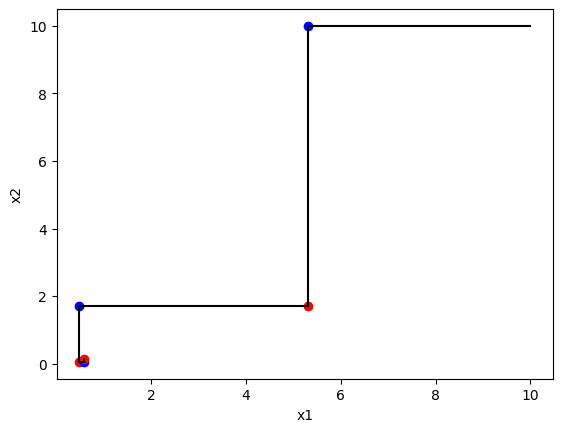

In [12]:
# Gibbs sampling

points_x1 = [10]
points_x2 = [10]

for i in range(3):
  x1 = norm.rvs(0.5*points_x2[-1], np.sqrt(0.75))
  plt.plot([points_x1[-1],x1],[points_x2[-1],points_x2[-1]], color='k')
  plt.scatter(x1,points_x2[-1], color='b')
  x2 = norm.rvs(0.5*x1, np.sqrt(0.75))
  plt.scatter(x1,x2, color='r')
  plt.plot([x1,x1],[points_x2[-1],x2], color='k')
  points_x1.append(x1)
  points_x2.append(x2)

plt.xlabel('x1')
plt.ylabel('x2')

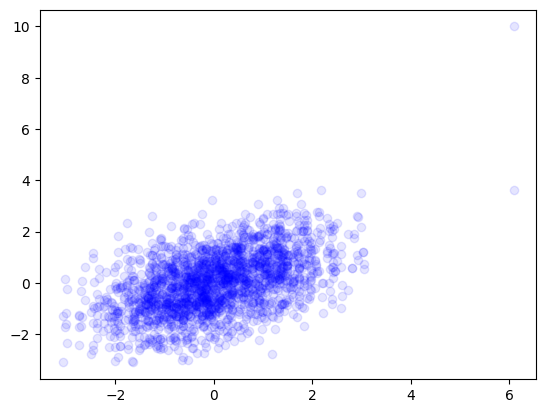

In [13]:
# Gibbs sampling

points_x1 = [10]
points_x2 = [10]

for i in range(1000):
  x1 = norm.rvs(0.5*points_x2[-1])
  plt.scatter(x1,points_x2[-1], color='b', alpha=0.1)
  x2 = norm.rvs(0.5*x1)
  plt.scatter(x1,x2, color='b', alpha=0.1)
  points_x1.append(x1)
  points_x2.append(x2)

It turns out that

$$ x_1 | x_2 \sim N(0.5 x_2, \sqrt{0.75}) $$
$$ x_2 | x_1 \sim N(0.5 x_1, \sqrt{0.75}) $$

Are the full conditionals of a Bivariate Normal $$N\left([0,0], \left(\begin{array}{cc}
1 & 0.5 \\
0.5 & 1
\end{array}\right)\right)$$

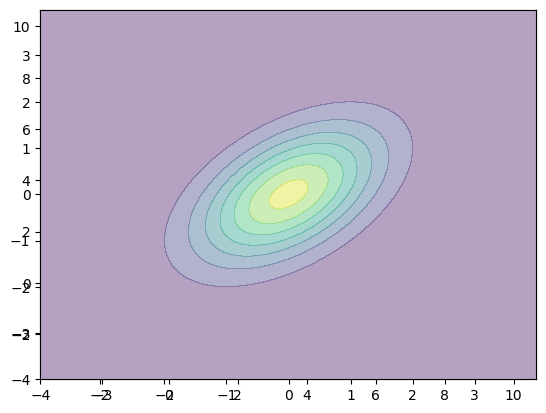

In [14]:
from scipy.stats import multivariate_normal

x, y = np.mgrid[-4:4:.01, -4:4:.01]
pos = np.dstack((x, y))
rv = multivariate_normal([0, 0], [[1, 0.5], [0.5, 1]])
fig2 = plt.figure()
plt.scatter(points_x1, points_x2, alpha=0.1)
ax2 = fig2.add_subplot(111)
ax2.contourf(x, y, rv.pdf(pos), alpha=0.4)

plt.show()

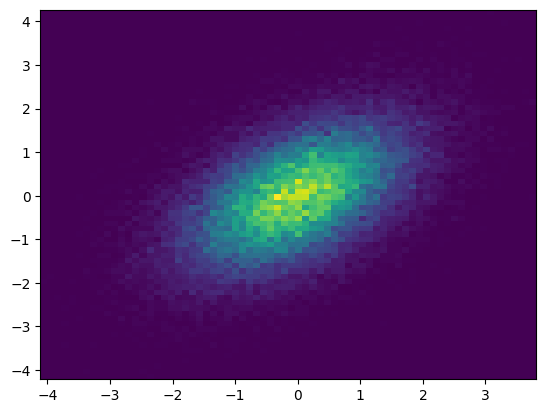

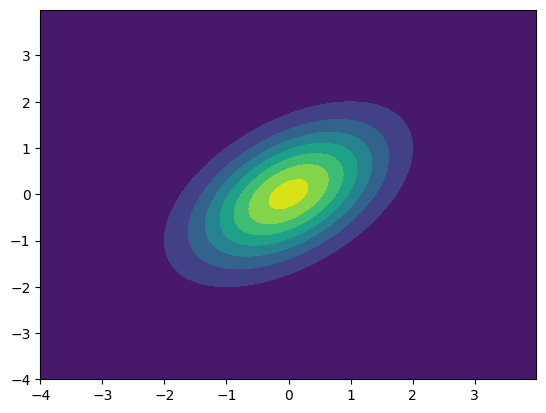

In [15]:
points_x1 = [1]
points_x2 = [1]

for i in range(50000):
  x1 = norm.rvs(0.5*points_x2[-1], np.sqrt(0.75))
  x2 = norm.rvs(0.5*x1, np.sqrt(0.75))
  points_x1.append(x1)
  points_x2.append(x2)

plt.hist2d(points_x1,points_x2, bins=70)
plt.show()

fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
ax2.contourf(x, y, rv.pdf(pos))
plt.show()

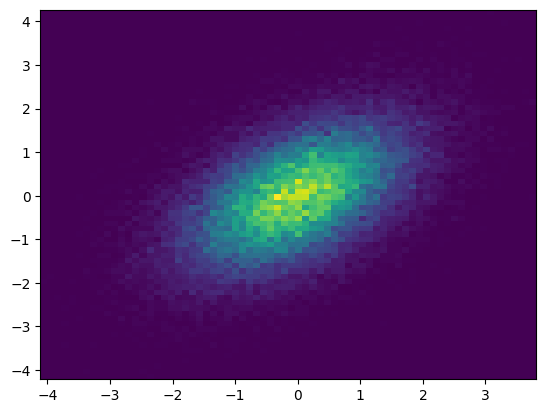

In [16]:
plt.hist2d(points_x1,points_x2, bins=70)
plt.show()

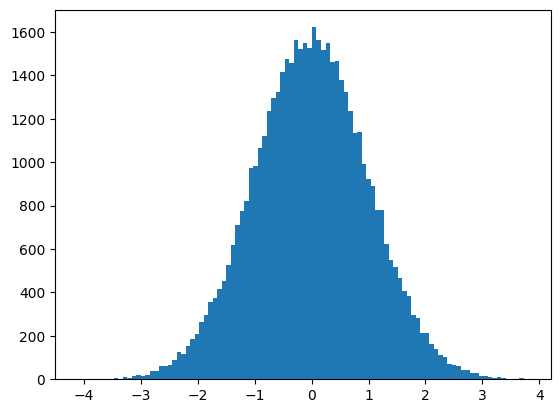

In [17]:
plt.hist(points_x1, bins=100)
plt.show()

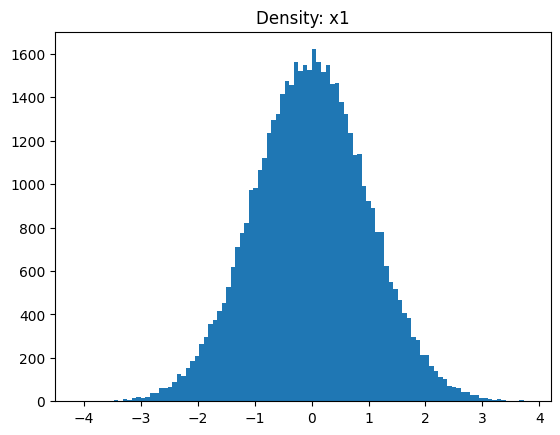

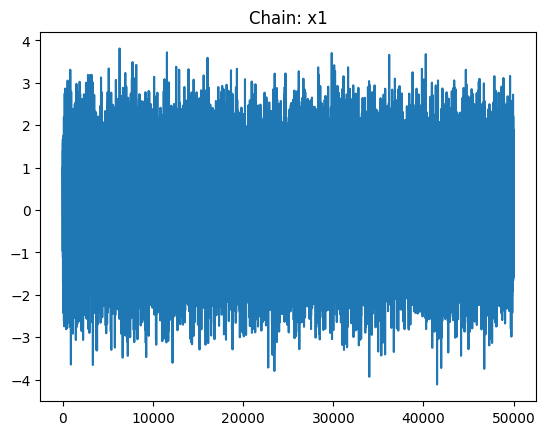

In [18]:
plt.hist(points_x1, bins=100)
plt.title('Density: x1')
plt.show()

plt.plot(points_x1)
plt.title('Chain: x1')
plt.show()

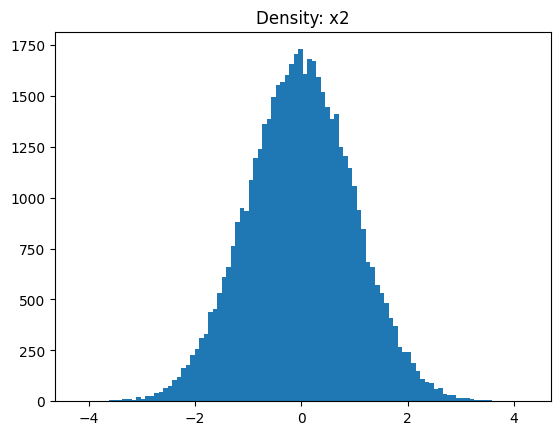

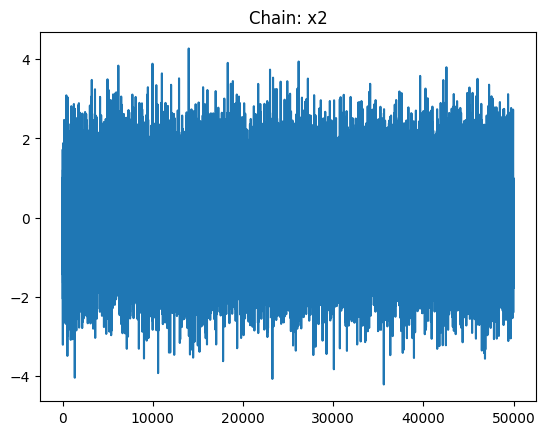

In [19]:
plt.hist(points_x2, bins=100)
plt.title('Density: x2')
plt.show()

plt.plot(points_x2)
plt.title('Chain: x2')
plt.show()